## **ETL Pipeline Dataset Global Unificado y Particionamiento**

A continuación, se crea el *dataset* global resultante de la concatenación de ambos **DataFrames** (`df_iemocap` y `df_meld`). Este *dataset* debe de contar con aquellas columnas que entrarán a la **Red Neuronal**, y algunas de las más importantes son: `video_path` (ruta al *clip* de vídeo de dicho turno o *utterance*), `audio_path` (ruta al audio asociado a dicho *clip* de vídeo), `text` (transcripción), `target_stress` (variable objetivo binaria).

Para esto, se requiere la normalización de los nombres de las variables en ambos datasets, además de llevar a cabo un proceso de selección de qué variables son las que se encontrar en el *dataset* final.

Inicialmente, se cargan las librerías y paquetes necesarios para la ejecución de este *notebook*.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

DATA_ROOT = "../data"  # Se indica la ruta donde se encuentran todos los datos para el proyecto

FIGURAS_PATH = "../figuras"  # Ruta donde se guardarán las figuras generadas

MELD_CLEAN_CSV = os.path.join(DATA_ROOT, "PROCESSED", "MELD_clean.csv") #Ruta al archivo CSV preprocesado de MELD 
IEMOCAP_CLEAN_CSV = os.path.join(DATA_ROOT, "PROCESSED", "IEMOCAP_clean.csv")#Ruta al archivo CSV preprocesado de IEMOCAP

GLOBAL_CSV_PATH = os.path.join(DATA_ROOT, "PROCESSED", "Multimodal_Stress_Dataset.csv")

Carga de ambos *datasets* (`IEMOCAP_clean.csv` y `MELD_clean.csv`) preprocesados.

In [2]:
# MELD_clean.csv

file_path = MELD_CLEAN_CSV
if os.path.exists(file_path):
    df_meld = pd.read_csv(file_path)
    display(df_meld.head()) 
else:
    print(f"No se encuentra el archivo en {file_path}")

,Dialogue_ID,Utterance_ID,Unique_ID,Utterance,Emotion,target_stress,video_path,audio_path,duration,Speaker,split,word_count
0,0,0,train_dia0_utt0,also I was the point person on my company's tr...,neutral,0,train_splits/dia0_utt0.mp4,MELD_Audio/train_dia0_utt0.wav,5.672333,Chandler,train,16
1,0,1,train_dia0_utt1,You must've had your hands full.,neutral,0,train_splits/dia0_utt1.mp4,MELD_Audio/train_dia0_utt1.wav,1.501500,The Interviewer,train,6
2,0,2,train_dia0_utt2,That I did. That I did.,neutral,0,train_splits/dia0_utt2.mp4,MELD_Audio/train_dia0_utt2.wav,2.919583,Chandler,train,6
3,0,3,train_dia0_utt3,So let's talk a little bit about your duties.,neutral,0,train_splits/dia0_utt3.mp4,MELD_Audio/train_dia0_utt3.wav,2.752750,The Interviewer,train,9
4,0,4,train_dia0_utt4,My duties? All right.,surprise,0,train_splits/dia0_utt4.mp4,MELD_Audio/train_dia0_utt4.wav,6.464792,Chandler,train,4


In [3]:
# IEMOCAP_clean.csv

# Carga de los datos ya preprocesados
file_path = IEMOCAP_CLEAN_CSV
if os.path.exists(file_path):
    df_iemocap = pd.read_csv(file_path)
    display(df_iemocap.head()) 
else:
    print(f"No se encuentra el archivo en {file_path}")

,Utterance_ID,Session,Emotion,Valence,Arousal,Dominance,Text,Start_Time,End_Time,Path_Wav_Audio,Path_Video_Processed,Path_Source_Video,duration,Dialogue_ID,word_count,target_stress
0,Ses01F_impro01_F000,1,neutral,2.5,2.5,2.5,Excuse me.,6.2901,8.2357,Session1/sentences/wav/Ses01F_impro01/Ses01F_i...,IEMOCAP_CLIPS/Ses01F_impro01_F000.mp4,Session1/dialog/avi/DivX/Ses01F_impro01.avi,1.9456,Ses01F_impro01,2,0
1,Ses01F_impro01_F001,1,neutral,2.5,2.5,2.5,Yeah.,10.0100,11.3925,Session1/sentences/wav/Ses01F_impro01/Ses01F_i...,IEMOCAP_CLIPS/Ses01F_impro01_F001.mp4,Session1/dialog/avi/DivX/Ses01F_impro01.avi,1.3825,Ses01F_impro01,1,0
2,Ses01F_impro01_F002,1,neutral,2.5,2.5,2.5,Is there a problem?,14.8872,18.0175,Session1/sentences/wav/Ses01F_impro01/Ses01F_i...,IEMOCAP_CLIPS/Ses01F_impro01_F002.mp4,Session1/dialog/avi/DivX/Ses01F_impro01.avi,3.1303,Ses01F_impro01,4,0
3,Ses01F_impro01_F005,1,neutral,2.5,3.5,2.0,Well what's the problem? Let me change it.,27.4600,31.4900,Session1/sentences/wav/Ses01F_impro01/Ses01F_i...,IEMOCAP_CLIPS/Ses01F_impro01_F005.mp4,Session1/dialog/avi/DivX/Ses01F_impro01.avi,4.0300,Ses01F_impro01,8,0
4,Ses01F_impro01_F006,1,frustration,2.0,3.5,3.5,What? I'm getting an ID. This is why I'm here....,38.9650,43.5900,Session1/sentences/wav/Ses01F_impro01/Ses01F_i...,IEMOCAP_CLIPS/Ses01F_impro01_F006.mp4,Session1/dialog/avi/DivX/Ses01F_impro01.avi,4.6250,Ses01F_impro01,14,1


---

### **Unificación y Concatenación.**

In [4]:
# <----------------------------- 1. PREPARACIÓN DE MELD PARA LA FUSIÓN ----------------------------->

# Seleccionamos solo las columnas útiles para el modelo:

cols_meld = ['Unique_ID', 'Dialogue_ID', 'video_path', 'audio_path', 'Utterance', 'Emotion', 'duration', 'split', 'target_stress']

df_meld_clean = df_meld[cols_meld].copy()
df_meld_clean['dataset_origin'] = 'MELD' # Se crea una nueva variable que indique de qué dataset proviene dicho registro 


# Renombramos los nombres de algunas de las columnas para que coincidan en ambos datasets, y sea mucho más claro:

# Utterance --> Transcription
# Unique_ID --> Utterance_ID
df_meld_clean = df_meld_clean.rename(columns={
    'Utterance': 'Transcription',
    'Unique_ID': 'Utterance_ID'
})

# Aseguramos además que los IDs sean strings (al igual que el Dialogue_ID en IEMOCAP)
df_meld_clean['Dialogue_ID'] = df_meld_clean['Dialogue_ID'].astype(str)

# <----------------------------- 2. PREPARACIÓN DE IEMOCAP PARA LA FUSIÓN  ----------------------------->

# Para que coincida con MELD, debemos añadir una nueva columna 'split', que por defecto vamos a asignarla No_Split

df_iemocap['split'] = 'No_Split'

# Seleccionamos las columnas útiles: 

cols_iemocap = ['Utterance_ID', 'Dialogue_ID', 'Path_Video_Processed', 'Path_Wav_Audio', 'Text', 'duration', 'target_stress', 'split']
df_iemocap_clean = df_iemocap[cols_iemocap].copy()

# Renombramos las rutas de IEMOCAP para que tengan el mismo nombre que en MELD:

# Path_Video_Processed -> video_path
# Path_Wav_Audio -> audio_path
# Text -> Transcription
df_iemocap_clean = df_iemocap_clean.rename(columns={
    'Path_Video_Processed': 'video_path',
    'Path_Wav_Audio': 'audio_path',
    'Text': 'Transcription'
})
df_iemocap_clean['dataset_origin'] = 'IEMOCAP' # Marcamos el origen de cada registro

# <----------------------------- 3. CONCATENACIÓN  ----------------------------->

# Definimos las columnas finales a seleccionar:
cols_final = ['Utterance_ID', 'Dialogue_ID', 'video_path', 'audio_path', 'Transcription', 'duration', 'split', 'target_stress', 'dataset_origin']
df_meld_clean = df_meld_clean[cols_final]
df_iemocap_clean = df_iemocap_clean[cols_final]
df_global = pd.concat([df_meld_clean, df_iemocap_clean], axis=0, ignore_index=True)

#  Normalización de rutas 
# Cambiamos todas las '\' por '/' para que funcione en Linux/Mac/Colab
df_global['video_path'] =  df_global['video_path'].str.replace('\\', '/', regex=False)
df_global['audio_path'] =  df_global['audio_path'].str.replace('\\', '/', regex=False)

# Verificación:
print(f"Dimensiones MELD: {df_meld_clean.shape}")
print(f"Dimensiones IEMOCAP:{df_iemocap_clean.shape}")
print(f"Dimensiones GLOBAL: {df_global.shape}")
print(df_global['dataset_origin'].value_counts())
print(print(df_global.groupby(['dataset_origin', 'split']).size()))

Dimensiones MELD: (13704, 9)
Dimensiones IEMOCAP:(7515, 9)
Dimensiones GLOBAL: (21219, 9)
dataset_origin
MELD       13704
IEMOCAP     7515
Name: count, dtype: int64
dataset_origin  split   
IEMOCAP         No_Split    7515
MELD            dev         1108
                test        2608
                train       9988
dtype: int64
None


Se explica a continuación el criterio de selección de columnas seguido:

1.  **Identificadores (`Utterance_ID`, `Dialogue_ID`):** Esenciales para reconstruir la secuencia temporal y el contexto de la conversación o *utterance*. Se conservan los identificadores únicos de cada turno de palabra y, crucialmente, el ID del diálogo al que pertenecen. Esta variable es fundamental para permitir que el modelo capture el contexto conversacional, analizando la secuencia temporal de interacciones en lugar de tratar cada frase como un evento aislado.
2.  **Rutas de Archivos (`video_path`, `audio_path`):** Punteros físicos a los datos crudos procesados.
3.  **Inputs del Modelo (`Transcription`, `duration`):** `Transcription` será la entrada del modelo de texto (BERT/RoBERTa/DeBERTa) y `duration` sirve para control de calidad y padding.
4.  **Target (`target_stress`):** La etiqueta de nuestra variable objetivo de **Estrés** (0/1).
5.  **Metadatos de Gestión (`split`, `dataset_origin`):**
    * `dataset_origin`: Esencial para poder filtrar o aplicar estrategias de entrenamiento diferenciadas según el *dataset* del que procede el dato.
    * `split`: Conservamos la partición original de MELD. Para IEMOCAP se asigna 'No_Split' inicialmente, luego se llevará a cabo el particionamiento.

Finalmente, guardamos el dataset **global** bajo el nombre de `Multimodal_Stress_Dataset.csv`. En este **CSV** único se incluye la concatenación de ambos datasets (`df_iemocap` y `df_meld`) y servirá como entrada, tras su debido particionamiento, a nuestro modelo.

In [5]:
df_global.to_csv(GLOBAL_CSV_PATH, index=False)
df_global.info()
df_global.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21219 entries, 0 to 21218
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Utterance_ID    21219 non-null  object 
 1   Dialogue_ID     21219 non-null  object 
 2   video_path      21219 non-null  object 
 3   audio_path      21219 non-null  object 
 4   Transcription   21219 non-null  object 
 5   duration        21219 non-null  float64
 6   split           21219 non-null  object 
 7   target_stress   21219 non-null  int64  
 8   dataset_origin  21219 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.5+ MB


,Utterance_ID,Dialogue_ID,video_path,audio_path,Transcription,duration,split,target_stress,dataset_origin
0,train_dia0_utt0,0,train_splits/dia0_utt0.mp4,MELD_Audio/train_dia0_utt0.wav,also I was the point person on my company's tr...,5.672333,train,0,MELD
1,train_dia0_utt1,0,train_splits/dia0_utt1.mp4,MELD_Audio/train_dia0_utt1.wav,You must've had your hands full.,1.501500,train,0,MELD
2,train_dia0_utt2,0,train_splits/dia0_utt2.mp4,MELD_Audio/train_dia0_utt2.wav,That I did. That I did.,2.919583,train,0,MELD
3,train_dia0_utt3,0,train_splits/dia0_utt3.mp4,MELD_Audio/train_dia0_utt3.wav,So let's talk a little bit about your duties.,2.752750,train,0,MELD
4,train_dia0_utt4,0,train_splits/dia0_utt4.mp4,MELD_Audio/train_dia0_utt4.wav,My duties? All right.,6.464792,train,0,MELD


-----
### **Particionamiento del *Dataset* Unificado**

#### **Tras los resultdos obtenidos del EDA** (Véase notebook `4_EDA_Multimodal.ipynb`)

En el EDA se ha observado que, debido principalmente al desbalanceo presente en MELD, y el escaso número de muestras de IEMOCAP, el problema del desbalanceo de clases también se encuentra presente en el corpus global unificado (aunque IEMOCAP sirve de data augmentation "natural" de MELD, al presentar tan pocos registros, no es suficiente), quedando finalmente el dataset global con un 23,3% de instancias positivas (Estrés) frente a un 76,7% de instancias negativas (No Estrés). 

Ante esta situación, lo primero que nos viene a la mente es realizar **data augmentation**. Algo que finalmente hemos descartado (se detalla el razonamiento en la memoria) ya que al necesitar que las tres modalidades estén correctamente alineadas (es decir, el audio, vídeo y texto deben corresponder al mismo turno de palabra de la misma persona que aparece en el clip de vídeo), llevar a cabo una aumento de datos nos obligaría a, o bien no tocar el contenido de lo que se dice (bajamos el brillo, añadimos ruido de fondo, y el texto no se tocaría), o bien optar por generación sintética y deepfakes, lo cual excede en complejidad a los objetivos marcados para este TFG.

El tratamiento del desbalanceo se realizará mediante técnicas de Machine Learning presentes en la literatura para la configuración del entrenamiento de nuestros modelos, que se detalla en la memoria. 

Por este motivo, no realizamos aumento de datos y conseguimos subsanar este problema sin modificar los datos originales, preservando la alineación y coherencia de las fuentes de datos. 

Una vez aclarado este punto, partiendo del dataset global unificado, los datos originales se dividen en *train*, *dev* y *test* de acuerdo a la siguiente estrategia:

* **MELD**: Se preserva el particionamiento original de los autores para servir de comparativa con el estado del arte.

* **IEMOCAP**: Para evitar el problema de **Speaker Bias** (Sesgo del Hablante), al contar con **5 sesiones** con actores distintos en cada una, se entrena con un subconjunto de esas particiones. El particionamiento se realiza en función de las sesiones de la siguiente manera (de acuerdo a lo observado en el EDA), siguiendo una estrategia 3-1-1:

    - **train**: Sesiones 1,3, y 4. Se asigna la **3** y **4** debido a que en el EDA de IEMOCAP se observa que estas sesiones tiene aproximadamente un 40% y 53% respectivamente de instancias positivas, superando al resto de sesiones. Permite aliviar mucho más el problema del desbalanceo en train. 
    - **dev**: Sesión 2. 
    - **test**: Sesión 5. 



In [6]:
########################## División (split) IEMOCAP #######################

#------ Estrategia 3-1-1 -------

# Train: Sesiones 1,3,4 
# Dev: Sesión 2 
# Test: Sesión 5 

# Función para asignar el split según la Sesión (Ses01, Ses03, Ses04 -> Train, Ses02 -> Dev, Ses05 -> Test)
def asignar_split_iemocap(utterance_id):
    if 'Ses01' in utterance_id or 'Ses03' in utterance_id or 'Ses04' in utterance_id:
        return 'train'
    elif 'Ses02' in utterance_id:
        return 'dev'   # Sesión 2 para validación
    elif 'Ses05' in utterance_id:
        return 'test'  # Sesión 5 para test 
    else:
        return 'train' # Por defecto 
    
# Creamos máscara para quedarnos únicamente con los registros IEMOCAP en el dataset global:
mask_iemocap = df_global['dataset_origin'] == 'IEMOCAP'

df_global.loc[mask_iemocap, 'split'] = df_global.loc[mask_iemocap, 'Utterance_ID'].apply(asignar_split_iemocap)

# ----------------------VERIFICACIÓN ------------------------------
print("Comprobación de Splits por Dataset:")
print(df_global.groupby(['dataset_origin', 'split']).size())

Comprobación de Splits por Dataset:
dataset_origin  split
IEMOCAP         dev      1370
                test     1649
                train    4496
MELD            dev      1108
                test     2608
                train    9988
dtype: int64


DESGLOSE POR FUENTE Y PARTICIÓN:
----------------------------------------
split            dev  test  train
dataset_origin                   
IEMOCAP         1370  1649   4496
MELD            1108  2608   9988

DISTRIBUCIÓN DE CLASES POR PARTICIÓN (GLOBAL):
------------------------------------------------------------
target_stress  0 (No Estrés)  1 (Estrés)
split                                   
dev                     1815         663
test                    3301         956
train                  11150        3334

6. DESGLOSE COMPLETO: FUENTE -> PARTICIÓN -> CLASE:
------------------------------------------------------------
target_stress         0 (No Estrés)  1 (Estrés)
dataset_origin split                           
IEMOCAP        dev              900         470
               test            1088         561
               train           2539        1957
MELD           dev              915         193
               test            2213         395
               train      

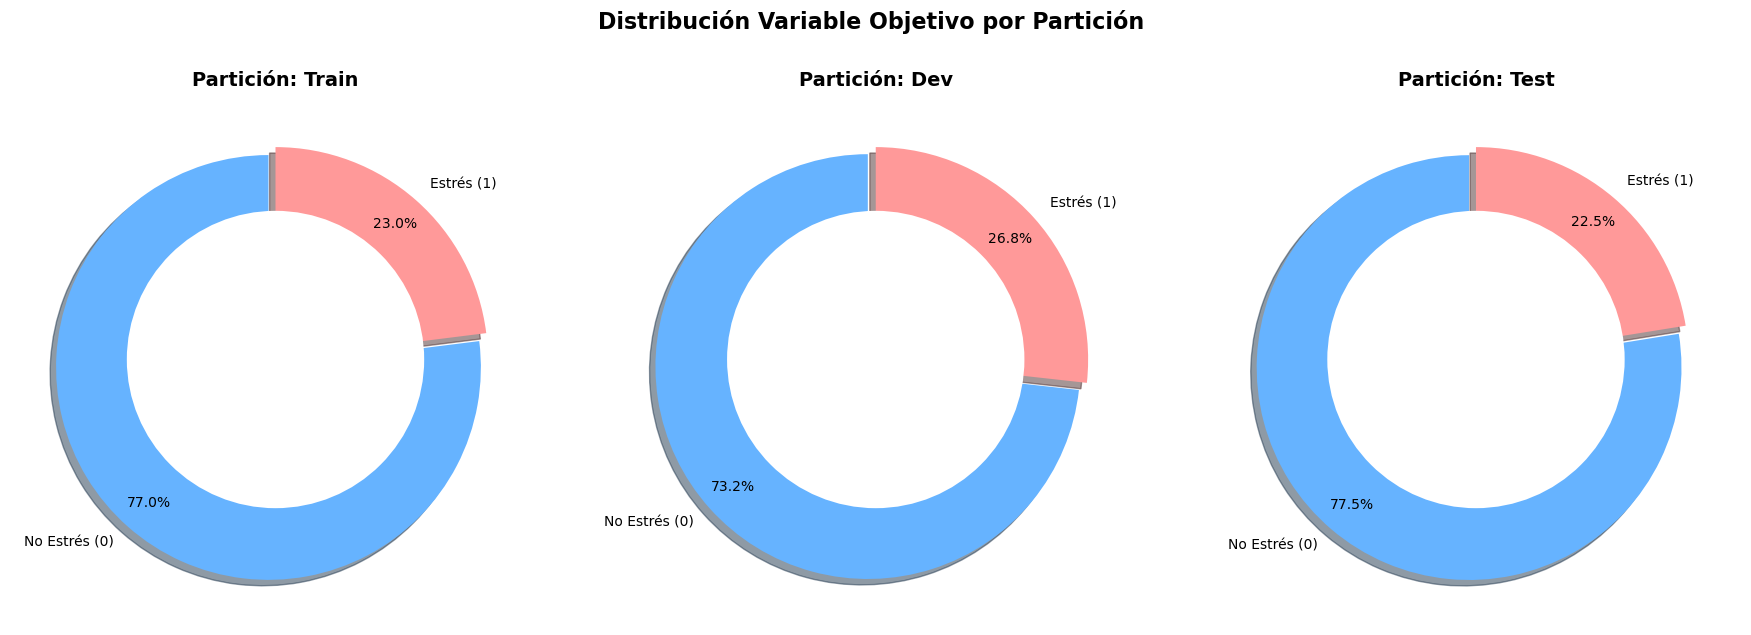

In [7]:
print("DESGLOSE POR FUENTE Y PARTICIÓN:")
print("-" * 40)
df_source_part = df_global.groupby(['dataset_origin', 'split']).size().unstack(fill_value=0)
print(df_source_part.to_string())

print("\nDISTRIBUCIÓN DE CLASES POR PARTICIÓN (GLOBAL):")
print("-" * 60)
df_part_class = df_global.groupby(['split', 'target_stress']).size().unstack(fill_value=0)
df_part_class.rename(columns={0: '0 (No Estrés)', 1: '1 (Estrés)'}, inplace=True)
print(df_part_class.to_string())

# 6. Desglose Total: Fuente + Partición + Clases
print("\n6. DESGLOSE COMPLETO: FUENTE -> PARTICIÓN -> CLASE:")
print("-" * 60)
df_full = df_global.groupby(['dataset_origin', 'split', 'target_stress']).size().unstack(fill_value=0)
df_full.rename(columns={0: '0 (No Estrés)', 1: '1 (Estrés)'}, inplace=True)
print(df_full.to_string())

particiones = ['train', 'dev', 'test']
etiquetas = ['No Estrés (0)', 'Estrés (1)']
colores = ['#66b3ff', '#ff9999'] # Azul para No Estrés, Rojo para Estrés

# Creamos una figura con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución Variable Objetivo por Partición', fontsize=16, fontweight='bold', y=1.05)

for i, particion in enumerate(particiones):
    # Filtramos el dataframe global por la partición actual
    df_part = df_global[df_global['split'] == particion]
    
    # Contamos los valores y los ordenamos por el índice (0 primero, 1 después)
    conteo = df_part['target_stress'].value_counts().sort_index()

    # Generamos el gráfico de donut en su eje correspondiente (axes[i])
    axes[i].pie(conteo, 
            labels=etiquetas, 
            colors=colores, 
            autopct='%1.1f%%', 
            startangle=90, 
            pctdistance=0.85, 
            explode=(0.05, 0),  
            shadow=True) 
    
    # Añadimos el centro en blanco para hacer el efecto Donut
    centre_circle = plt.Circle((0,0), 0.70, fc='white') 
    axes[i].add_artist(centre_circle)
    
    # Título individual para cada subgráfico
    axes[i].set_title(f'Partición: {particion.capitalize()}', fontsize=14, fontweight='bold')

plt.tight_layout()

# Guardamos la imagen 
plt.savefig(os.path.join(FIGURAS_PATH, 'Fig_Global_Particiones_PieChartEstres.png'), dpi=300, bbox_inches='tight')
plt.show()

Mostramos dos gráficas que muestren el particionamiento realizado y el resultado final de nuestro dataset definitivo:

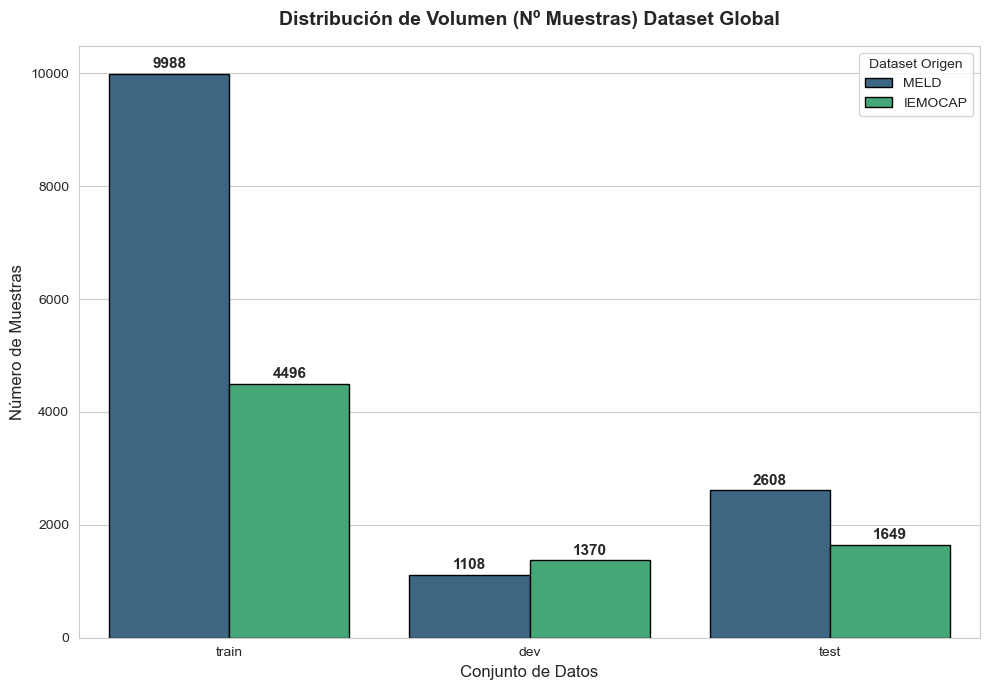

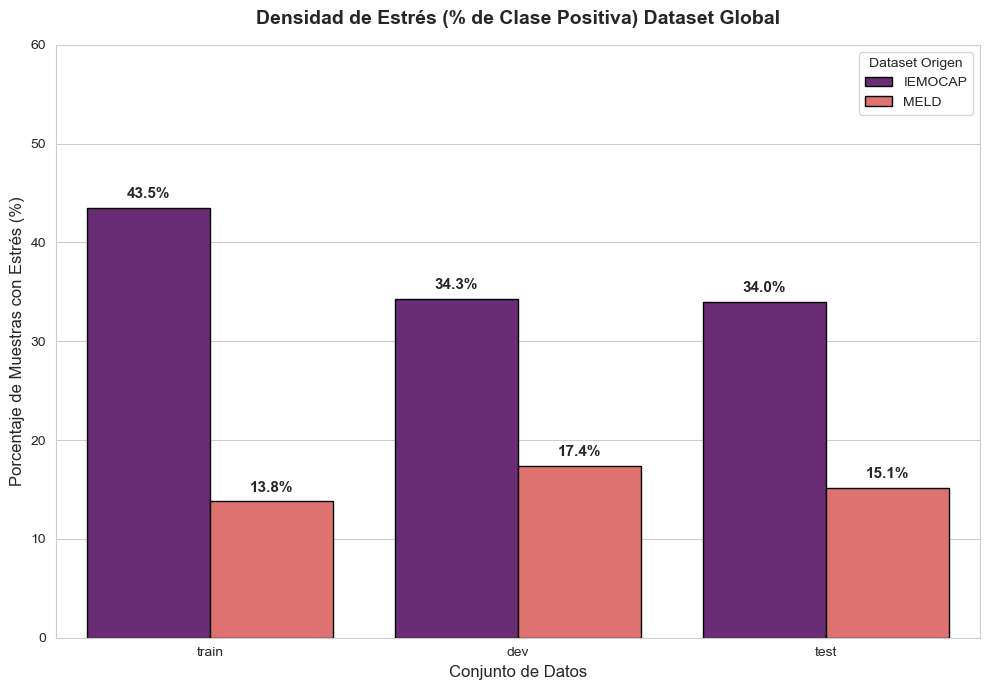

In [8]:
# Configuración estética
sns.set_style("whitegrid")

plt.figure(figsize=(10,7))

order_splits = ['train', 'dev', 'test']


# GRÁFICO 1 (IZQUIERDA): Volumen de datos en cada partición


ax1 = sns.countplot(data=df_global, x='split', hue='dataset_origin', 
              order=order_splits, palette='viridis', edgecolor='black')

plt.title('Distribución de Volumen (Nº Muestras) Dataset Global', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Conjunto de Datos', fontsize=12)
plt.ylabel('Número de Muestras', fontsize=12)
plt.legend(title='Dataset Origen')

# Etiquetas con el número total
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.text(p.get_x() + p.get_width()/2., height + 100, 
                f'{int(height)}', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_PATH, 'Fig_Global_Splits_Stress.png'), dpi=300)
plt.show()

# GRÁFICO 2 (DERECHA): Densidad de estrés

plt.figure(figsize=(10,7))

# Calculamos el porcentaje de estrés por grupo
# Agrupamos por Origen y Split, calculamos la media del target (0 o 1) y multiplicamos por 100
stress_ratios = df_global.groupby(['dataset_origin', 'split'])['target_stress'].mean().reset_index()
stress_ratios['stress_pct'] = stress_ratios['target_stress'] * 100

ax2=sns.barplot(data=stress_ratios, x='split', y='stress_pct', hue='dataset_origin',
            order=order_splits, palette='magma', edgecolor='black')

plt.title('Densidad de Estrés (% de Clase Positiva) Dataset Global', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Conjunto de Datos', fontsize=12)
plt.ylabel('Porcentaje de Muestras con Estrés (%)', fontsize=12)
plt.ylim(0, 60) # Fijamos límite para ver mejor (IEMOCAP suele estar entre 40-50%)
plt.legend(title='Dataset Origen')


for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.text(p.get_x() + p.get_width()/2., height + 1, 
                f'{height:.1f}%', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_PATH, 'Fig_Global_Splits_Stress_2.png'), dpi=300)
plt.show()

Vemos que gracias a IEMOCAP hemos logrado corregir de forma leve ese desbalanceo crítico de MELD, permitiendo, con aproximadamente un 20% de instancias positivas (Estrés) en cada partición, y aplicando las técnicas de Machine Learning estándar en la literatura para el desbalanceo, poder lograr entrenar modelos que consigan un buen rendimiento a pesar de tener un dataset desbalanceado. 

In [10]:
# Actualizamos el dataset guardado con el particionamiento realizado:
df_global.to_csv(GLOBAL_CSV_PATH, index=False)
df_global.info()
df_global.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21219 entries, 0 to 21218
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Utterance_ID    21219 non-null  object 
 1   Dialogue_ID     21219 non-null  object 
 2   video_path      21219 non-null  object 
 3   audio_path      21219 non-null  object 
 4   Transcription   21219 non-null  object 
 5   duration        21219 non-null  float64
 6   split           21219 non-null  object 
 7   target_stress   21219 non-null  int64  
 8   dataset_origin  21219 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.5+ MB


,Utterance_ID,Dialogue_ID,video_path,audio_path,Transcription,duration,split,target_stress,dataset_origin
0,train_dia0_utt0,0,train_splits/dia0_utt0.mp4,MELD_Audio/train_dia0_utt0.wav,also I was the point person on my company's tr...,5.672333,train,0,MELD
1,train_dia0_utt1,0,train_splits/dia0_utt1.mp4,MELD_Audio/train_dia0_utt1.wav,You must've had your hands full.,1.501500,train,0,MELD
2,train_dia0_utt2,0,train_splits/dia0_utt2.mp4,MELD_Audio/train_dia0_utt2.wav,That I did. That I did.,2.919583,train,0,MELD
3,train_dia0_utt3,0,train_splits/dia0_utt3.mp4,MELD_Audio/train_dia0_utt3.wav,So let's talk a little bit about your duties.,2.752750,train,0,MELD
4,train_dia0_utt4,0,train_splits/dia0_utt4.mp4,MELD_Audio/train_dia0_utt4.wav,My duties? All right.,6.464792,train,0,MELD
